# Notebook 8 — Strategy is not engagement *(optional)*

*SWC ENC 2026 · behaviour module*

Every mouse so far licked throughout the session. Real mice **disengage** — they
stop licking for stretches, then re-engage. A natural worry: is "disengaged" just
another strategy the model should include? Piet et al. (Figure 3) argue no —
**engagement is a separate axis from strategy**. Because we generate engagement as
its own latent, *independent* of the strategy weights, we can demonstrate that
cleanly: the analysis recovers the two axes as separately as we built them.

**In this notebook you will:**
1. Meet a mouse that disengages, and see it in the licking rate.
2. Recover the hidden engagement state from **rolling rates** (Fig 3A–B).
3. Show the recovered **strategy** is unchanged by engagement.

---
**The paper panel this notebook reproduces**

<img src="../assets/paper/fig3b.png" width="720">

*Fig. 3B — one session's lick-bout rate and reward rate over time, with the
engaged/disengaged threshold. This notebook recovers that engagement state and
shows it is a separate axis from strategy.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import swcbehav as sb

# A visual-strategy mouse that also drifts in and out of task engagement.
eng = sb.make_mouse("visual", seed=2, engaged=True)
tbl = eng.table
print(f"fraction of time truly engaged: {tbl['true_engaged'].mean():.2f}")

fraction of time truly engaged: 0.85


## 1. Disengagement in the raw behavior

When the mouse disengages, its licking nearly stops. Here is the smoothed
lick-bout rate across the session, with the *true* disengaged periods shaded. The
rate collapses in the shaded stretches — engagement gates licking on top of
whatever strategy the mouse is running.

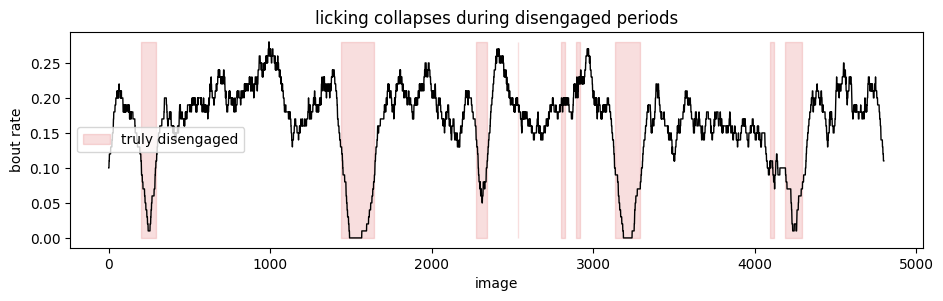

In [2]:
def rolling_rate(events, window=100):
    box = np.ones(window) / window
    return np.convolve(np.asarray(events, float), box, mode="same")

bout_rate = rolling_rate(tbl["bout_start"].to_numpy())
plt.figure(figsize=(11, 2.8))
plt.plot(bout_rate, color="k", lw=1)
diseng = ~tbl["true_engaged"].to_numpy()
plt.fill_between(np.arange(len(tbl)), 0, bout_rate.max(), where=diseng,
                 color="tab:red", alpha=0.15, label="truly disengaged")
plt.xlabel("image"); plt.ylabel("bout rate"); plt.legend()
plt.title("licking collapses during disengaged periods")
plt.show()

## 2. Recovering engagement from rolling rates

We don't get the true engagement state for real mice — we infer it. Following the
paper, we compute **rolling rates** of licking and reward and call the mouse
*disengaged* wherever the lick-bout rate falls below a threshold.

**Exercise 1.** Complete `classify_engaged`: smooth the bout-start vector into a
rate and threshold it. Then we'll check the recovered state against the truth.

> **Check / unstuck.** The recovered engagement should match the hidden truth on
> **~90%+** of images. Stuck? The solutions copy has it.

In [3]:
def classify_engaged(sess, window=100, threshold=0.05):
    rate = rolling_rate(sess.table["bout_start"].to_numpy(), window)
    return rate > threshold

engaged_hat = classify_engaged(eng)
agreement = (engaged_hat == eng.table["true_engaged"].to_numpy()).mean()
print(f"recovered engagement matches the hidden truth on {agreement:.1%} of images")

recovered engagement matches the hidden truth on 92.6% of images


The rolling-rate classifier recovers the hidden engagement latent well; the
mismatches sit at the transitions, where smoothing blurs the exact switch time.
The paper draws its engaged/disengaged boundary in the 2D plane of lick-bout rate
vs reward rate — the two are tightly linked, since rewards can only come while
licking:

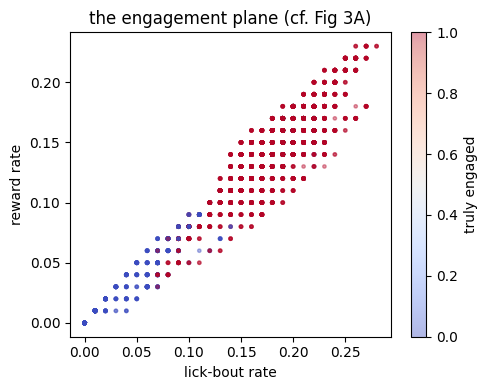

In [4]:
reward_rate = rolling_rate(tbl["reward"].to_numpy())
plt.figure(figsize=(5, 4))
plt.scatter(bout_rate, reward_rate, c=tbl["true_engaged"].to_numpy(),
            cmap="coolwarm", s=6, alpha=0.4)
plt.xlabel("lick-bout rate"); plt.ylabel("reward rate")
plt.title("the engagement plane (cf. Fig 3A)")
plt.colorbar(label="truly engaged"); plt.tight_layout(); plt.show()

## 3. Strategy survives engagement

Now the key claim. If engagement were just another strategy, adding it would
distort the strategy readout. It doesn't. We compute the **strategy index** on the
engaged images of this disengaging mouse and compare it to the *same* mouse run
fully engaged — the strategy should be unchanged, because we built engagement to
act only on the overall drive to lick, not on the visual/timing balance.

**Exercise 2.** Complete `strategy_index_on`: restrict $X, y$ to a boolean mask of
images, then run the ablation from Notebook 5.

> **Check / unstuck.** The two strategy indices (fully-engaged vs engaged-only)
> should land close together (~+0.22). Stuck? The solutions copy has it.

In [5]:
def strategy_index_on(sess, mask=None):
    X, cols = sb.build_design_matrix(sess.table)
    y = sess.table["bout_start"].to_numpy().astype(float)
    if mask is not None:
        X, y = X[mask], y[mask]
    d = sb.ablation_loglik_deltas(X, y, cols)
    return d["visual"] - d["timing"]

fully_engaged = sb.make_mouse("visual", seed=2)   # same strategy, no disengagement
si_reference = strategy_index_on(fully_engaged)
si_engaged_only = strategy_index_on(eng, mask=engaged_hat)
print(f"strategy index, fully-engaged mouse      : {si_reference:+.4f}")
print(f"strategy index, engaged images only     : {si_engaged_only:+.4f}")

strategy index, fully-engaged mouse      : +0.2379
strategy index, engaged images only     : +0.2203


The two strategy indices land in the same place: **engagement did not change the
strategy we recover.** One latent controls *whether* the mouse is playing; a
separate set of weights controls *how* it plays. We recover them as independently
as we built them — which is exactly the paper's conclusion that strategy and
engagement are distinct axes.

## Wrap-up

Engagement gates overall licking; strategy sets the visual/timing balance. They're
separate knobs in the generator, and the analysis pulls them apart: rolling rates
recover engagement, ablation recovers strategy, and neither contaminates the
other.

That completes the behaviour module — Figures 1–3 of Piet et al., built up from a
design matrix to a drifting-strategy model, every step checked against a ground
truth you controlled.